In [47]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
!unzip /content/barille.zip

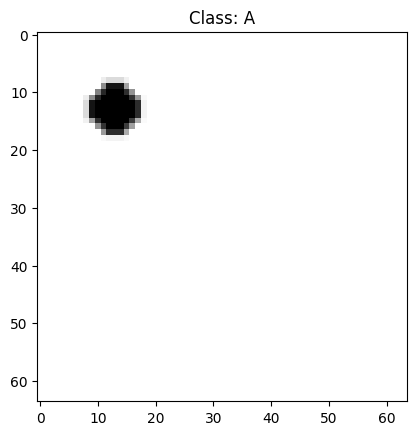

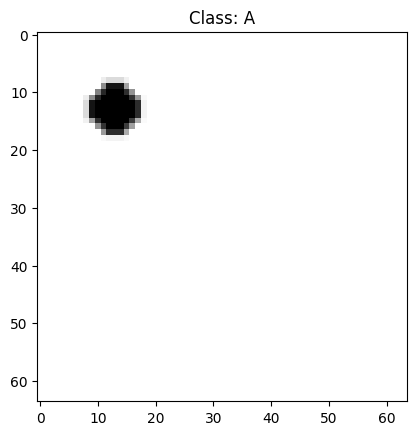

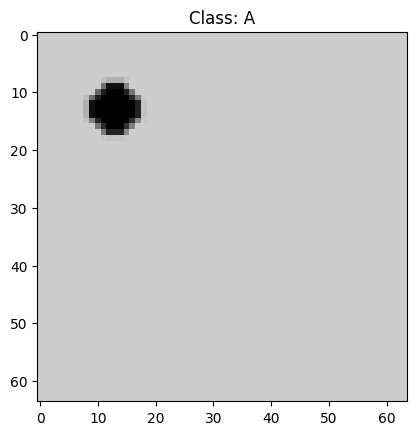

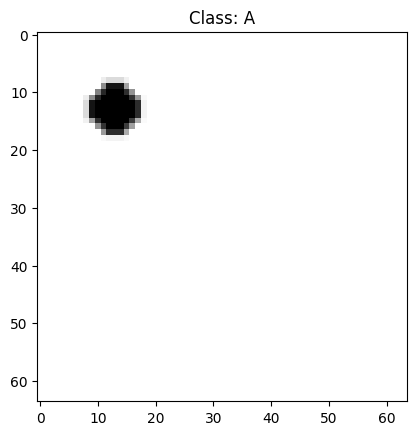

Total images loaded: 500
Labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [49]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

data = []
labels = []

classes = ['A', 'B', 'C', 'D', 'E']
base_path = "/content/Braille Alphabet Image Dataset (A–Z)"
img_size = 64

for label, category in enumerate(classes):
    path = os.path.join(base_path, category)

    for img in os.listdir(path):
        img_path = os.path.join(path, img)

        image = cv2.imread(img_path)
        image = cv2.resize(image, (64, 64))

        data.append(image)
        labels.append(label)
        if len(data) < 5:
          plt.imshow(image)
          plt.title("Class: " + category)
          plt.show()

        # show only first image of each class

print("Total images loaded:", len(data))
print("Labels:", labels[:10])


In [50]:
Adata = np.array(data)
labels = np.array(labels)

data = data / 255.0

print(data.shape)
print(labels.shape)

(500, 64, 64, 3)
(500,)


In [51]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(400, 64, 64, 3)
(100, 64, 64, 3)
(400,)
(100,)


In [52]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(5, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,597 (3.14 MB)

 Trainable params: 822,597 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test)
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.3650 - loss: 1.6062 - val_accuracy: 0.6600 - val_loss: 1.5142
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.6775 - loss: 1.2833 - val_accuracy: 0.7200 - val_loss: 0.9074
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.9725 - loss: 0.4555 - val_accuracy: 1.0000 - val_loss: 0.1453
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 1.0000 - loss: 0.0379 - val_accuracy: 1.0000 - val_loss: 0.0085
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 9.1199e-04
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 1.0000 - loss: 6.5887e-04 - val_accuracy: 1.0000 - val_loss: 6.6822e-04
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 1.0000 - loss: 5.1653e-04 - 

In [54]:
from sklearn.metrics import confusion_matrix,classification_report

In [55]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [56]:
cm = confusion_matrix(y_test, y_pred_classes)

print(cm)

[[28  0  0  0  0]
 [ 0 14  0  0  0]
 [ 0  0 10  0  0]
 [ 0  0  0 24  0]
 [ 0  0  0  0 24]]


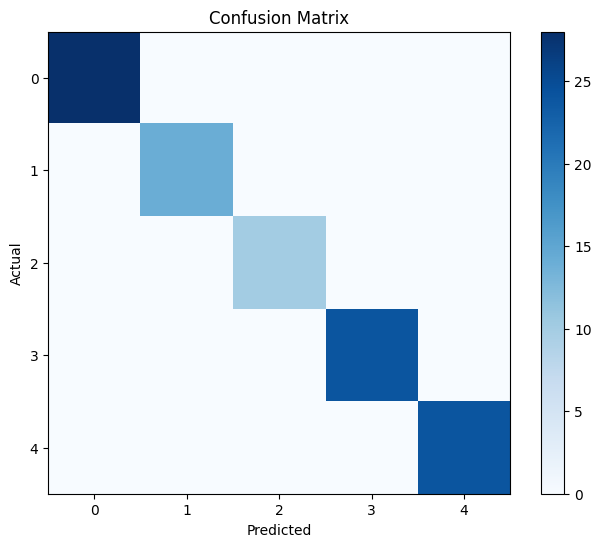

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
print(np.unique(y_test))
print(np.unique(y_pred_classes))

[0 1 2 3 4]
[0 1 2 3 4]


In [59]:
print(classification_report(
    y_test,
    y_pred_classes,
    labels=[0,1,2,3,4],
    target_names=classes
))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00        28
           B       1.00      1.00      1.00        14
           C       1.00      1.00      1.00        10
           D       1.00      1.00      1.00        24
           E       1.00      1.00      1.00        24

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [67]:
model.save("braille_cnn_model.h5")

In [64]:
path = "/content/Braille Alphabet Image Dataset (A–Z)/D"
print(os.listdir(path))

['D_24.png', 'D_19.png', 'D_22.png', 'D_42.png', 'D_87.png', 'D_6.png', 'D_63.png', 'D_54.png', 'D_57.png', 'D_48.png', 'D_3.png', 'D_52.png', 'D_92.png', 'D_56.png', 'D_66.png', 'D_55.png', 'D_16.png', 'D_89.png', 'D_61.png', 'D_53.png', 'D_45.png', 'D_82.png', 'D_91.png', 'D_44.png', 'D_11.png', 'D_85.png', 'D_90.png', 'D_59.png', 'D_70.png', 'D_79.png', 'D_62.png', 'D_74.png', 'D_97.png', 'D_75.png', 'D_8.png', 'D_37.png', 'D_71.png', 'D_10.png', 'D_80.png', 'D_96.png', 'D_9.png', 'D_67.png', 'D_31.png', 'D_25.png', 'D_4.png', 'D_29.png', 'D_40.png', 'D_47.png', 'D_26.png', 'D_14.png', 'D_58.png', 'D_28.png', 'D_36.png', 'D_27.png', 'D_98.png', 'D_50.png', 'D_78.png', 'D_7.png', 'D_51.png', 'D_5.png', 'D_72.png', 'D_39.png', 'D_94.png', 'D_34.png', 'D_35.png', 'D_1.png', 'D_77.png', 'D_12.png', 'D_69.png', 'D_49.png', 'D_84.png', 'D_20.png', 'D_33.png', 'D_0.png', 'D_13.png', 'D_60.png', 'D_17.png', 'D_68.png', 'D_18.png', 'D_38.png', 'D_23.png', 'D_83.png', 'D_43.png', 'D_2.png', '

In [65]:
test_img = cv2.imread("/content/Braille Alphabet Image Dataset (A–Z)/D/D_1.png")
test_img = cv2.resize(test_img, (64,64))
test_img = test_img / 255.0
test_img = np.expand_dims(test_img, axis=0)

prediction = model.predict(test_img)

print(prediction)
print("Predicted:", classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
[[1.8408992e-10 2.1417531e-11 3.3536769e-06 9.9998021e-01 1.6391619e-05]]
Predicted: D
